## Cell 1 — Install dependencies

In [ ]:
!pip install gymnasium stable-baselines3 pandas matplotlib seaborn -q

## Cell 2 — `IAMEnv`: MDP environment

In [ ]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces


class IAMEnv(gym.Env):
    """
    IAM MDP Environment — implements M = (S, A, P, R, gamma).

    State S = [S_bio | S_context | S_risk] decomposition:
        obs[0]  typing_speed    — S_bio
        obs[1]  mouse_dynamics  — S_bio
        obs[2]  location_trust  — S_context
        obs[3]  time_norm       — S_context
        obs[4]  device_trust    — S_context
        obs[5]  bayesian_trust  — S_risk (mu_t, Fragkos et al. approximation)

    Actions A = {0: grant, 1: deny, 2: challenge (MFA), 3: step_up_auth}

    Reward  R = alpha * R_security + beta * R_friction
        Both components normalised to [-1, +1].

    Transition P:
        is_threat is sampled per step as a sigmoid function of the observable
        state vector — NOT as a fixed scenario-level constant.

        trust_signal = (location_trust + device_trust + bayesian_trust) / 3
        p_threat = sigmoid(-8 * (trust_signal - 0.5)) * p_threat_scale
                   + p_threat_base

        The scenario parameters p_threat_base / p_threat_scale set the
        operating window on the sigmoid (threat regime), but within each
        step the threat label is causally linked to obs[2,4,5]. The agent
        must therefore learn to read the state.

    Scenarios (training): legitimate, behavioral_drift, credential_theft,
                          false_positive
    Scenario (held-out):  novel_attack
    """

    metadata = {"render_modes": []}

    # Scenario parameters
    # p_threat_base  : minimum p(threat) when trust_signal -> 1.0
    # p_threat_scale : added probability when trust_signal -> 0.0
    SCENARIO_PARAMS = {
        # ── Training scenarios ─────────────────────────────────────────────
        "legitimate": dict(
            bio_mean=0.75, bio_std=0.07, bio_md_offset=0.00,
            loc_mean=0.85, loc_std=0.07,
            dt_mean=0.80,  dt_std=0.07,
            tn_low=0.2,    tn_high=0.8,
            init_trust=0.80,
            p_threat_base=0.02,    # floor: ~2% at high trust
            p_threat_scale=0.18,   # ceiling: ~20% at near-zero trust
        ),
        "behavioral_drift": dict(
            bio_mean=0.55, bio_std=0.12, bio_md_offset=-0.05,
            loc_mean=0.40, loc_std=0.12,
            dt_mean=0.50,  dt_std=0.10,
            tn_low=0.1,    tn_high=0.9,
            init_trust=0.55,
            p_threat_base=0.10,
            p_threat_scale=0.55,   # broad range — key discriminative scenario
        ),
        "credential_theft": dict(
            bio_mean=0.35, bio_std=0.14, bio_md_offset=0.05,
            loc_mean=0.20, loc_std=0.12,
            dt_mean=0.25,  dt_std=0.10,
            tn_low=0.0,    tn_high=1.0,
            init_trust=0.30,
            p_threat_base=0.35,
            p_threat_scale=0.55,
        ),
        "false_positive": dict(
            bio_mean=0.62, bio_std=0.11, bio_md_offset=-0.03,
            loc_mean=0.58, loc_std=0.11,
            dt_mean=0.55,  dt_std=0.09,
            tn_low=0.15,   tn_high=0.85,
            init_trust=0.60,
            p_threat_base=0.03,
            p_threat_scale=0.20,   # legit-dominant, tests over-blocking
        ),
        "novel_attack": dict(
            bio_mean=0.58, bio_std=0.16, bio_md_offset=0.08,
            loc_mean=0.15, loc_std=0.10,
            dt_mean=0.20,  dt_std=0.09,
            tn_low=0.0,    tn_high=1.0,
            init_trust=0.25,
            p_threat_base=0.30,
            p_threat_scale=0.60,
        ),
    }

    def __init__(self, scenario="legitimate", alpha=0.7, beta=0.3, max_steps=200):
        super().__init__()
        self.scenario  = scenario
        self.alpha     = alpha
        self.beta      = beta
        self.max_steps = max_steps
        self.p         = self.SCENARIO_PARAMS[scenario]

        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(6,), dtype=np.float32
        )
        self.action_space = spaces.Discrete(4)

        self.bayesian_trust = self.p["init_trust"]
        self.current_step   = 0
        self._last_obs      = None

    # ── Sampling helpers ───────────────────────────────────────────────────

    def _sample_bio(self):
        ts = float(np.clip(
            np.random.normal(self.p["bio_mean"], self.p["bio_std"]), 0, 1
        ))
        md = float(np.clip(
            np.random.normal(
                self.p["bio_mean"] + self.p["bio_md_offset"],
                self.p["bio_std"] * 1.1
            ), 0, 1
        ))
        return ts, md

    def _sample_context(self):
        lt = float(np.clip(
            np.random.normal(self.p["loc_mean"], self.p["loc_std"]), 0, 1
        ))
        tn = float(np.random.uniform(self.p["tn_low"], self.p["tn_high"]))
        dt = float(np.clip(
            np.random.normal(self.p["dt_mean"], self.p["dt_std"]), 0, 1
        ))
        return lt, tn, dt

    def _sample_threat(self, obs):
        """
        Threat sampling conditioned on the observable state.

        trust_signal = mean(location_trust, device_trust, bayesian_trust)
        p_threat = sigmoid(-8 * (trust_signal - 0.5)) * p_threat_scale
                   + p_threat_base

        The sigmoid maps trust_signal in [0,1] to a monotonically decreasing
        threat probability. Scenario parameters shift the operating window.
        The agent must read obs[2], obs[4], obs[5] to discriminate.
        """
        trust_signal = (float(obs[2]) + float(obs[4]) + float(obs[5])) / 3.0
        sigmoid_val  = 1.0 / (1.0 + np.exp(8.0 * (trust_signal - 0.5)))
        p = float(np.clip(
            sigmoid_val * self.p["p_threat_scale"] + self.p["p_threat_base"],
            0.0, 1.0
        ))
        return bool(np.random.random() < p)

    def _update_bayesian_trust(self, action, is_threat):
        """
        Delta-rule approximation of the Bayesian trust update (Fragkos et al.).
        The Gaussian noise N(0, 0.02) is a process-noise term modelling
        unobserved contextual variation (sensor noise, micro-behavioural
        fluctuation) — standard in stochastic MDP environments.
        """
        if action == 0:    # grant
            delta = -0.12 if is_threat else +0.04
        elif action == 1:  # deny
            delta = +0.03 if is_threat else -0.02
        elif action == 2:  # challenge
            delta = +0.02 if is_threat else +0.01
        else:              # step_up_auth
            delta = +0.03 if is_threat else +0.01

        self.bayesian_trust = float(np.clip(
            self.bayesian_trust + delta + np.random.normal(0, 0.02), 0, 1
        ))

    def _get_obs(self):
        ts, md     = self._sample_bio()
        lt, tn, dt = self._sample_context()
        obs = np.array(
            [ts, md, lt, tn, dt, self.bayesian_trust], dtype=np.float32
        )
        self._last_obs = obs
        return obs

    # ── Gymnasium API ──────────────────────────────────────────────────────

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step   = 0
        self.bayesian_trust = float(np.clip(
            np.random.normal(self.p["init_trust"], 0.05), 0, 1
        ))
        obs = self._get_obs()
        return obs, {}

    def step(self, action):
        self.current_step += 1
        obs       = self._get_obs()
        is_threat = self._sample_threat(obs)

        # R_security (normalised to [-1, +1])
        sec_map = {
            0: (-1.0 if is_threat else +1.0),   # grant
            1: (+1.0 if is_threat else -1.0),   # deny
            2: (+0.6 if is_threat else -0.2),   # challenge
            3: (+0.8 if is_threat else -0.4),   # step_up
        }
        # R_friction (normalised to [-1, +1])
        fric_map = {
            0: (0.0  if is_threat else +1.0),
            1: (0.0  if is_threat else -1.0),
            2: (+0.3 if is_threat else -0.4),
            3: (+0.3 if is_threat else -0.7),
        }

        r_sec  = sec_map[int(action)]
        r_fric = fric_map[int(action)]
        reward = self.alpha * r_sec + self.beta * r_fric

        self._update_bayesian_trust(int(action), is_threat)

        terminated = self.current_step >= self.max_steps
        return obs, reward, terminated, False, {"is_threat": is_threat, "action": action}


## Cell 3 — Rule-based baseline agent

In [ ]:
class RuleBasedAgent:
    """
    Static rule-based agent — threshold-based IAM policy.

    Observation index mapping (matches IAMEnv._get_obs exactly):
        obs[0] = typing_speed      (not used by rule logic)
        obs[1] = mouse_dynamics    (not used by rule logic)
        obs[2] = location_trust
        obs[3] = time_norm         (not used by rule logic)
        obs[4] = device_trust
        obs[5] = bayesian_trust    (risk proxy)

    Limitation: uses bayesian_trust which is dynamic —
    a faithful RBAC baseline would use static attributes only.
    Acknowledged as a stylised reference point, not a production baseline.
    """

    def predict(self, obs, deterministic=True):
        location_trust = obs[2]
        device_trust   = obs[4]
        bayesian_trust = obs[5]

        if bayesian_trust < 0.30 or (location_trust < 0.20 and device_trust < 0.30):
            return 1, None   # deny

        elif bayesian_trust < 0.50 or location_trust < 0.40 or device_trust < 0.35:
            return 2, None   # MFA challenge

        elif device_trust < 0.55:
            return 3, None   # step-up auth

        else:
            return 0, None   # grant

class PureRBACAgent:
    """
    Faithful RBAC abstraction: uses ONLY static role/resource attributes.
    No dynamic trust score, no context signals.
    Represents a static role matrix: high-trust role → grant, else deny.
    This is the true lower bound of static policy systems.
    """
    def predict(self, obs, deterministic=True):
        # RBAC only knows the user's role tier, approximated here
        # by the initial device_trust as a static role proxy.
        # It has NO access to bayesian_trust, location_trust, or
        # any session-level dynamic signal.
        device_tier = obs[4]   # static device registration = role proxy

        if device_tier >= 0.6:
            return 0, None   # grant — trusted role
        elif device_tier >= 0.35:
            return 2, None   # challenge — limited role
        else:
            return 1, None   # deny — unknown/unregistered role

## Cell 4 — Train DQN on training scenarios

In [ ]:
from stable_baselines3 import DQN
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.vec_env import DummyVecEnv

TRAIN_SCENARIOS  = ["legitimate", "behavioral_drift", "credential_theft", "false_positive"]
EVAL_SCENARIOS   = TRAIN_SCENARIOS
HOLDOUT_SCENARIO = "novel_attack"   # unseen during training


def make_env(scenario, alpha=0.7, beta=0.3, max_steps=200):
    return lambda: IAMEnv(scenario=scenario, alpha=alpha, beta=beta, max_steps=max_steps)


# Sanity-check environment API
env_check = IAMEnv(scenario="legitimate")
check_env(env_check, warn=True)
print("Environment structure valid")

# Train on all four training scenarios simultaneously
print("Training DQN on mixed 4-scenario environment (1M steps)...")
mixed_envs = DummyVecEnv([
    make_env("legitimate",       alpha=0.70, beta=0.30),
    make_env("behavioral_drift", alpha=0.85, beta=0.15),
    make_env("credential_theft", alpha=0.70, beta=0.30),
    make_env("false_positive",   alpha=0.70, beta=0.30),
])

dqn_model = DQN(
    "MlpPolicy",
    mixed_envs,
    learning_rate=5e-4,
    buffer_size=200_000,
    learning_starts=2_000,
    batch_size=64,
    gamma=0.95,
    exploration_fraction=0.2,
    verbose=0,
)
dqn_model.learn(total_timesteps=1000000)
mixed_envs.close()
print("Training complete")


Environment structure valid
Training DQN on mixed 4-scenario environment (1M steps)...
Training complete


## Cell 5 — Evaluation function

In [ ]:
import pandas as pd


def evaluate_agent(agent, scenario, n_episodes=200, agent_type="RL"):
    env = IAMEnv(scenario=scenario, max_steps=100)

    granted_threats = 0   # False Accepts  (FA)
    blocked_threats = 0   # True Detections (TD)
    denied_legit    = 0   # False Rejects  (FR)
    granted_legit   = 0   # True Accepts   (TA)
    friction_events = 0   # challenge + step_up on legit ONLY
    threat_total    = 0
    legit_total     = 0

    for _ in range(n_episodes):
        obs, _ = env.reset()
        done   = False
        while not done:
            if agent_type == "RL":
                action, _ = agent.predict(obs, deterministic=True)
            else:
                action, _ = agent.predict(obs)

            obs, _, terminated, truncated, info = env.step(int(action))
            done      = terminated or truncated
            is_threat = info["is_threat"]

            if is_threat:
                threat_total += 1
                if action == 0:
                    granted_threats += 1   # FA
                else:
                    blocked_threats += 1   # TD
            else:
                legit_total += 1
                if action == 1:
                    denied_legit += 1      # FR
                else:
                    granted_legit += 1     # TA
                # AFS: only challenge(2) and step_up(3)
                if action in [2, 3]:
                    friction_events += 1

    env.close()

    FAR = granted_threats / threat_total if threat_total > 0 else 0.0
    TDR = blocked_threats / threat_total if threat_total > 0 else 1.0
    FRR = denied_legit    / legit_total  if legit_total  > 0 else 0.0
    AFS = friction_events / legit_total  if legit_total  > 0 else 0.0

    return {
        "Scenario":       scenario,
        "Agent":          agent_type,
        "FAR":            round(FAR, 3),
        "TDR":            round(TDR, 3),
        "FRR":            round(FRR, 3),
        "AFS":            round(AFS, 3),
        "n_threat_steps": threat_total,
        "n_legit_steps":  legit_total,
    }

## Cell 6 — In-distribution evaluation: DQN vs Rule-Based

In [ ]:
rule_agent = RuleBasedAgent()
results    = []

for scenario in EVAL_SCENARIOS:
    results.append(evaluate_agent(dqn_model,  scenario, n_episodes=200, agent_type="DQN"))
    results.append(evaluate_agent(rule_agent, scenario, n_episodes=200, agent_type="Rule-Based"))

df = pd.DataFrame(results)
print("In-distribution evaluation (training scenarios):")
print(df.to_string(index=False))

pure_rbac = PureRBACAgent()
results_3way = []
for agent, name in [(dqn_model,"DQN"),(rule_agent,"Enhanced Rule-Based"),(pure_rbac,"Pure RBAC")]:
    results_3way.append(
        evaluate_agent(agent, "credential_theft", n_episodes=200, agent_type=name)
    )
df_3way = pd.DataFrame(results_3way)
print("\nThree-way baseline comparison (credential_theft scenario):")
print(df_3way.to_string(index=False))

In-distribution evaluation (training scenarios):
        Scenario      Agent   FAR   TDR   FRR   AFS  n_threat_steps  n_legit_steps
      legitimate        DQN 0.964 0.036 0.013 0.025             577          19423
      legitimate Rule-Based 1.000 0.000 0.000 0.000             526          19474
behavioral_drift        DQN 0.436 0.564 0.014 0.469            7772          12228
behavioral_drift Rule-Based 0.150 0.850 0.001 0.854            5835          14165
credential_theft        DQN 0.020 0.980 0.014 0.964           13549           6451
credential_theft Rule-Based 0.000 1.000 0.349 0.651           13762           6238
  false_positive        DQN 0.950 0.050 0.013 0.034            1349          18651
  false_positive Rule-Based 0.456 0.544 0.000 0.532            1366          18634


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Three-way baseline comparison (credential_theft scenario):
        Scenario               Agent   FAR   TDR   FRR   AFS  n_threat_steps  n_legit_steps
credential_theft                 DQN 0.023 0.977 0.010 0.970           13539           6461
credential_theft Enhanced Rule-Based 0.000 1.000 0.358 0.642           13799           6201
credential_theft           Pure RBAC 0.000 1.000 0.845 0.154           13858           6142


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Cell 7 — Held-out generalisation: `novel_attack` scenario

In [ ]:
print("Held-out generalisation evaluation (novel_attack — unseen during training):")
holdout_dqn  = evaluate_agent(dqn_model,  HOLDOUT_SCENARIO, n_episodes=200, agent_type="DQN")
holdout_rule = evaluate_agent(rule_agent, HOLDOUT_SCENARIO, n_episodes=200, agent_type="Rule-Based")
df_holdout   = pd.DataFrame([holdout_dqn, holdout_rule])
print(df_holdout.to_string(index=False))


Held-out generalisation evaluation (novel_attack — unseen during training):
    Scenario      Agent   FAR   TDR   FRR   AFS  n_threat_steps  n_legit_steps
novel_attack        DQN 0.043 0.957 0.011 0.945           14053           5947
novel_attack Rule-Based 0.000 1.000 0.611 0.389           14139           5861


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Cell 8 - Adversarial Robustness Sanity Check

In [ ]:
def adversarial_perturbation_test(agent, scenario, epsilon=0.05, n_episodes=100):
    """
    Sanity check: add uniform noise to biometric features (obs[0], obs[1])
    simulating an attacker who slightly manipulates their behavioral signals
    to appear more legitimate. Epsilon controls perturbation magnitude.
    """
    env = IAMEnv(scenario=scenario, max_steps=100)
    granted_threats = 0
    threat_total    = 0

    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False
        while not done:
            # Perturb only biometric features — attacker controls typing/mouse
            perturbed_obs = obs.copy()
            perturbed_obs[0] = np.clip(obs[0] + epsilon, 0, 1)  # inflate typing_speed
            perturbed_obs[1] = np.clip(obs[1] + epsilon, 0, 1)  # inflate mouse_dynamics

            action, _ = agent.predict(perturbed_obs, deterministic=True)
            obs, _, terminated, truncated, info = env.step(int(action))
            done = terminated or truncated

            if info["is_threat"] and action == 0:
                granted_threats += 1
            if info["is_threat"]:
                threat_total += 1

    env.close()
    adv_FAR = granted_threats / threat_total if threat_total > 0 else 0.0
    return round(adv_FAR, 3)

# Test on credential_theft — strongest threat scenario
clean_FAR = evaluate_agent(dqn_model, "credential_theft", n_episodes=200, agent_type="DQN")["FAR"]
adv_FAR_005 = adversarial_perturbation_test(dqn_model, "credential_theft", epsilon=0.05)
adv_FAR_010 = adversarial_perturbation_test(dqn_model, "credential_theft", epsilon=0.10)
adv_FAR_020 = adversarial_perturbation_test(dqn_model, "credential_theft", epsilon=0.20)

print(f"Clean FAR (credential_theft):          {clean_FAR}")
print(f"Adversarial FAR (epsilon=0.05):        {adv_FAR_005}")
print(f"Adversarial FAR (epsilon=0.10):        {adv_FAR_010}")
print(f"Adversarial FAR (epsilon=0.20):        {adv_FAR_020}")
print(f"FAR degradation at epsilon=0.05:       +{round(adv_FAR_005 - clean_FAR, 3)}")
print(f"\nConclusion: {'Robust' if adv_FAR_020 - clean_FAR < 0.10 else 'Sensitive'} "
      f"to biometric perturbation (Δ at ε=0.20: +{round(adv_FAR_020 - clean_FAR, 3)})")

Clean FAR (credential_theft):          0.021
Adversarial FAR (epsilon=0.05):        0.018
Adversarial FAR (epsilon=0.10):        0.027
Adversarial FAR (epsilon=0.20):        0.076
FAR degradation at epsilon=0.05:       +-0.003

Conclusion: Robust to biometric perturbation (Δ at ε=0.20: +0.055)


## Cell 9 — Visualisation: DQN vs Rule-Based across training scenarios

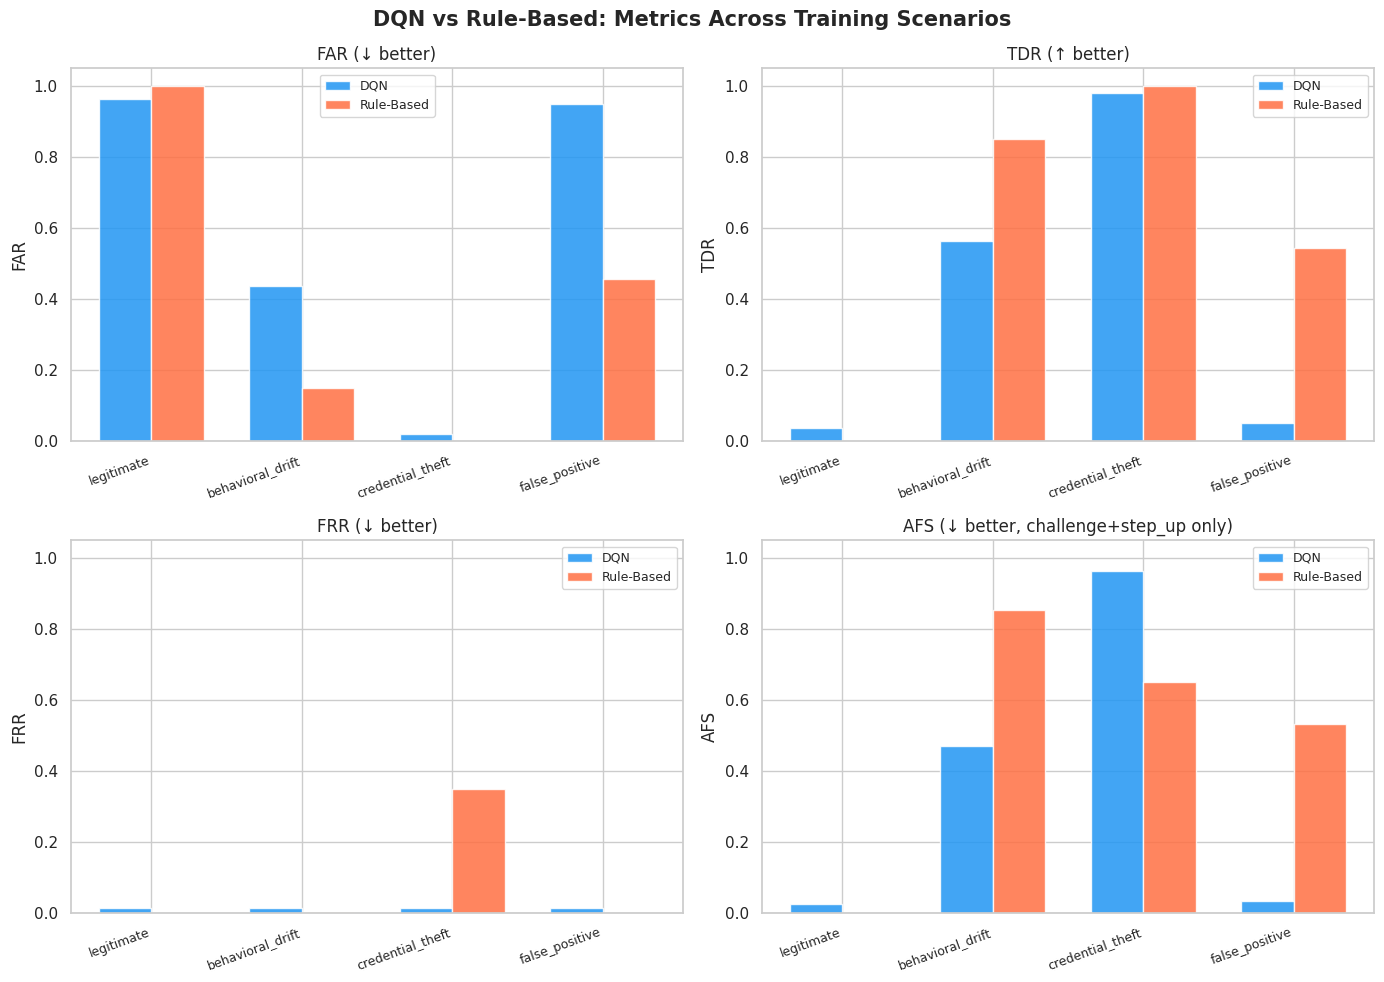

Chart saved as iam_comparison.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "DQN vs Rule-Based: Metrics Across Training Scenarios",
    fontsize=15, fontweight="bold"
)

metrics = ["FAR", "TDR", "FRR", "AFS"]
titles  = ["FAR (↓ better)", "TDR (↑ better)", "FRR (↓ better)", "AFS (↓ better, challenge+step_up only)"]
colors  = {"DQN": "#2196F3", "Rule-Based": "#FF7043"}

for ax, metric, title in zip(axes.flat, metrics, titles):
    dqn_vals  = df[df["Agent"] == "DQN"][metric].values
    rule_vals = df[df["Agent"] == "Rule-Based"][metric].values
    x = np.arange(len(EVAL_SCENARIOS))
    w = 0.35
    ax.bar(x - w/2, dqn_vals,  w, label="DQN",       color=colors["DQN"],        alpha=0.85)
    ax.bar(x + w/2, rule_vals, w, label="Rule-Based", color=colors["Rule-Based"], alpha=0.85)
    ax.set_title(title, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(EVAL_SCENARIOS, rotation=20, ha="right", fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.set_ylabel(metric)

plt.tight_layout()
plt.savefig("iam_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as iam_comparison.png")


## Cell 10 — Sensitivity / Pareto analysis

In [ ]:
PARETO_EVAL_SCENARIO = "behavioral_drift"   # single balanced scenario
alpha_values         = [0.3, 0.5, 0.7, 0.9]
pareto_results       = []

for alpha in alpha_values:
    beta = round(1.0 - alpha, 1)
    print(f"  Training agent alpha={alpha}, beta={beta} (200k steps)...")

    envs = DummyVecEnv([make_env(s, alpha=alpha, beta=beta) for s in TRAIN_SCENARIOS])
    model = DQN(
        "MlpPolicy",
        envs,
        learning_rate=5e-4,
        buffer_size=50_000,
        learning_starts=2_000,
        batch_size=64,
        gamma=0.95,
        exploration_fraction=0.2,
        verbose=0,
    )
    model.learn(total_timesteps=200_000)
    envs.close()

    row = evaluate_agent(model, PARETO_EVAL_SCENARIO, n_episodes=200, agent_type="DQN")
    pareto_results.append({
        "alpha": alpha,
        "beta":  beta,
        "FAR":   row["FAR"],
        "FRR":   row["FRR"],
        "AFS":   row["AFS"],
        "TDR":   row["TDR"],
    })
    print(f"    -> FAR={row['FAR']:.3f}  TDR={row['TDR']:.3f}  FRR={row['FRR']:.3f}  AFS={row['AFS']:.3f}")

df_pareto = pd.DataFrame(pareto_results)
print(f"\nSensitivity analysis on '{PARETO_EVAL_SCENARIO}' scenario:")
print(df_pareto.to_string(index=False))


  Training agent alpha=0.3, beta=0.7 (200k steps)...
    -> FAR=0.927  TDR=0.073  FRR=0.012  AFS=0.056
  Training agent alpha=0.5, beta=0.5 (200k steps)...
    -> FAR=0.873  TDR=0.127  FRR=0.013  AFS=0.111
  Training agent alpha=0.7, beta=0.3 (200k steps)...
    -> FAR=0.390  TDR=0.610  FRR=0.010  AFS=0.529
  Training agent alpha=0.9, beta=0.1 (200k steps)...
    -> FAR=0.376  TDR=0.624  FRR=0.013  AFS=0.530

Sensitivity analysis on 'behavioral_drift' scenario:
 alpha  beta   FAR   FRR   AFS   TDR
   0.3   0.7 0.927 0.012 0.056 0.073
   0.5   0.5 0.873 0.013 0.111 0.127
   0.7   0.3 0.390 0.010 0.529 0.610
   0.9   0.1 0.376 0.013 0.530 0.624


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Cell 11 — Pareto visualisation

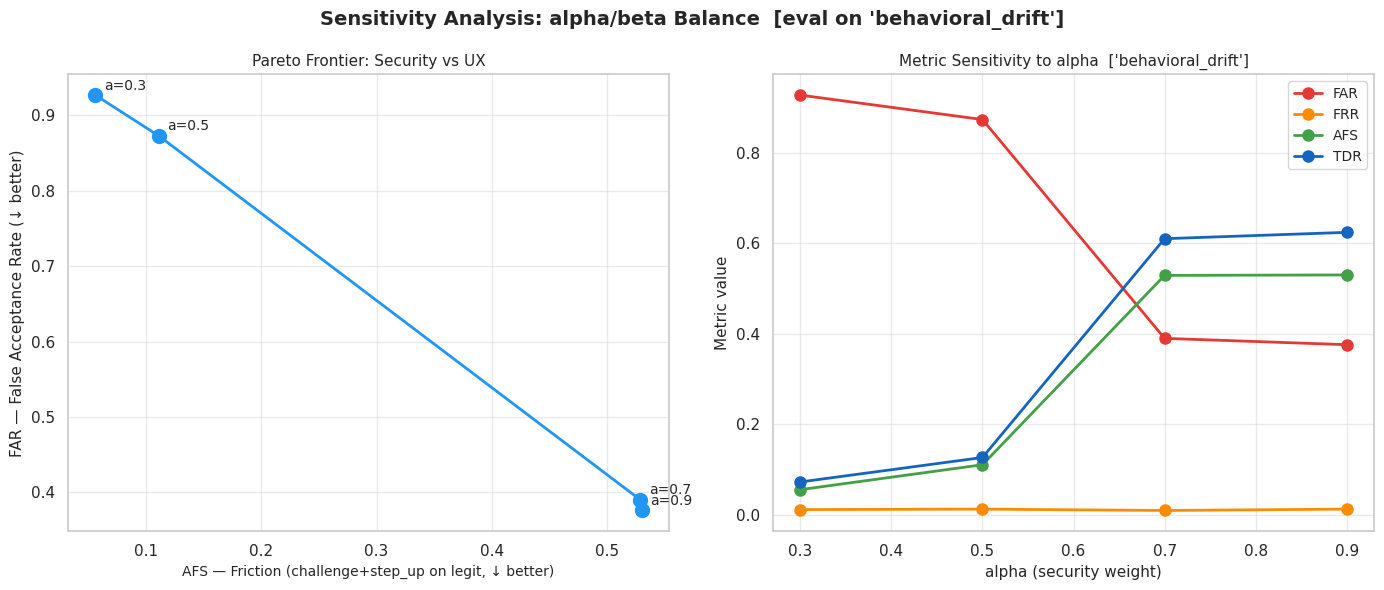

Saved as pareto_sensitivity.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    f"Sensitivity Analysis: alpha/beta Balance  [eval on '{PARETO_EVAL_SCENARIO}']",
    fontsize=14, fontweight="bold"
)

# Left: Pareto frontier — AFS (friction) vs FAR (security failure)
ax = axes[0]
ax.plot(
    df_pareto["AFS"], df_pareto["FAR"],
    "o-", color="#2196F3", linewidth=2, markersize=10
)
for _, row in df_pareto.iterrows():
    ax.annotate(
        f"a={row['alpha']}",
        (row["AFS"], row["FAR"]),
        textcoords="offset points", xytext=(6, 4), fontsize=10
    )
ax.set_xlabel("AFS — Friction (challenge+step_up on legit, ↓ better)", fontsize=10)
ax.set_ylabel("FAR — False Acceptance Rate (↓ better)", fontsize=11)
ax.set_title("Pareto Frontier: Security vs UX", fontsize=11)
ax.grid(True, alpha=0.4)

# Right: all four metrics vs alpha
ax2 = axes[1]
colors_m = {"FAR": "#e53935", "FRR": "#FB8C00", "AFS": "#43A047", "TDR": "#1565C0"}
for metric, color in colors_m.items():
    ax2.plot(
        df_pareto["alpha"], df_pareto[metric],
        "o-", label=metric, color=color, linewidth=2, markersize=8
    )
ax2.set_xlabel("alpha (security weight)", fontsize=11)
ax2.set_ylabel("Metric value", fontsize=11)
ax2.set_title(f"Metric Sensitivity to alpha  ['{PARETO_EVAL_SCENARIO}']", fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("pareto_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as pareto_sensitivity.png")
